##Description
This dataset contains 1,000 customer records suitable for segmentation, clustering, and behavioral analysis tasks. It includes demographic attributes, income information, and a spending behavior score designed for analytical modeling.

##Data Characteristics
Age distribution is concentrated within economically active ranges (primarily 22–49).
Income values follow realistic career progression patterns.
Spending Score reflects behavioral variation across age and income groups.
Each feature column (excluding CustomerID) contains a small number of missing values (3–6 per column) to support data cleaning and preprocessing exercises.
Value ranges are controlled to maintain economic plausibility.

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
hosseinbadrnezhad_mall_customer_segmentation_dataset_path = kagglehub.dataset_download('hosseinbadrnezhad/mall-customer-segmentation-dataset')

print('Data source import complete.')


100%|██████████| 7.32k/7.32k [00:00<00:00, 11.9MB/s]

Extracting files...
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os

# Load dataset
df = pd.read_csv(os.path.join(hosseinbadrnezhad_mall_customer_segmentation_dataset_path, 'store_customers.csv'))

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [6]:
df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,0.0,39.0,59.9,58.0
1,1001,0.0,34.0,48.4,37.0
2,1002,1.0,40.0,70.5,26.0
3,1003,1.0,47.0,81.1,30.0
4,1004,1.0,33.0,42.1,58.0


In [7]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].mean(), inplace=True)
df['Spending Score (1-100)'].fillna(df['Spending Score (1-100)'].mean(), inplace=True)

/tmp/ipykernel_2571/3387136651.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_2571/3387136651.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [8]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


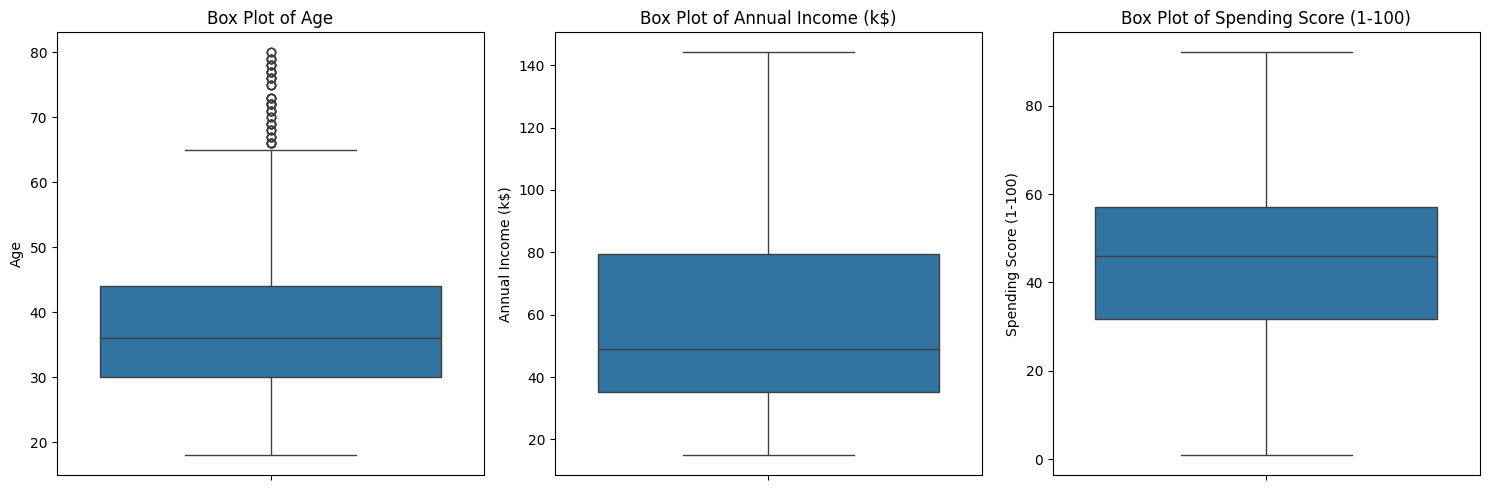

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  1000 non-null   float64
 2   Age                     1000 non-null   float64
 3   Annual Income (k$)      1000 non-null   float64
 4   Spending Score (1-100)  1000 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


In [12]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

In [13]:
X['Spending_Efficiency'] = X['Spending Score (1-100)'] / X['Annual Income (k$)']

In [14]:
X = X.drop(['Spending Score (1-100)', 'Annual Income (k$)'], axis=1)

In [15]:
print(X)

      Age  Spending_Efficiency
0    39.0             0.968280
1    34.0             0.764463
2    40.0             0.368794
3    47.0             0.369914
4    33.0             1.377672
..    ...                  ...
995  80.0             0.007502
996  44.0             0.484262
997  46.0             0.384047
998  28.0             1.291028
999  67.0             0.009276

[1000 rows x 2 columns]


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

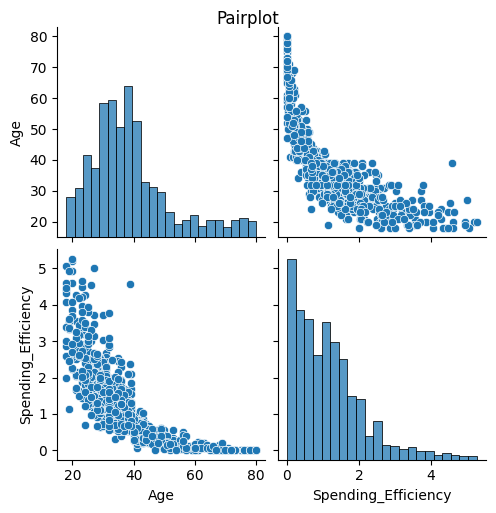

In [17]:
sns.pairplot(X)
plt.suptitle("Pairplot",y=1.01)
plt.show()

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

In [19]:
for k, score in zip(K_range, sil_scores):
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.463
K=3, Silhouette Score=0.492
K=4, Silhouette Score=0.486
K=5, Silhouette Score=0.463
K=6, Silhouette Score=0.430
K=7, Silhouette Score=0.409
K=8, Silhouette Score=0.389
K=9, Silhouette Score=0.380


In [20]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [21]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,50.976190,91.189683,21.925761
1,32.465824,41.553692,53.543208
2,22.480289,17.140741,66.481481
3,70.218750,108.707803,4.156250
4,26.639571,27.308667,59.490973
5,39.790385,65.696384,39.234395


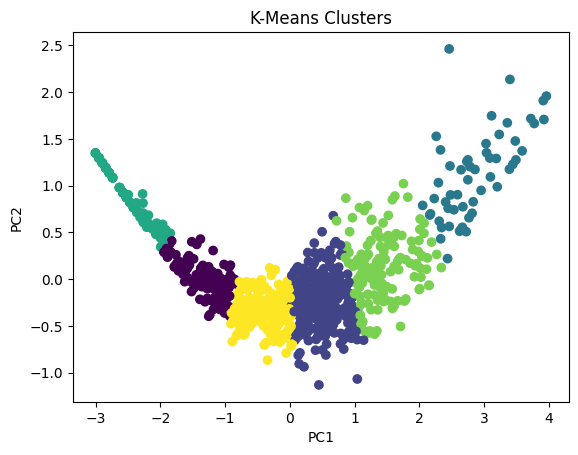

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [25]:
bins = [0, 30, 36, 46, 61, 100]
labels = ['0-29', '30-35', '36-45', '46-60', '61+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_group_summary = df.groupby('AgeGroup', observed=False)[['Age', 'Spending Score (1-100)', 'Annual Income (k$)']].sum()
print(age_group_summary)

                   Age  Spending Score (1-100)  Annual Income (k$)
AgeGroup                                                          
0-29       5771.000000            13314.645875         6509.698193
30-35      7429.000000            12195.291751         9272.449096
36-45     12704.613682            14010.291751        19693.400000
46-60      6290.000000             2726.645875        11237.600000
61+        6741.000000              399.000000        10435.949096
